Installing all required Libraries 

In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np


from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error)

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df= pd.read_csv('well.csv')

print(df.head())



   Depth (ft)  Weight on bit (k-lbs)  Temperature Out (deg F)  \
0       85.18                    0.0                    93.49   
1       86.18                    0.0                    93.52   
2       87.23                    0.0                    94.25   
3       88.26                    0.0                    94.44   
4       89.36                    0.0                    94.48   

   Temperature In(deg F)  Pit Total (bbls)  Pump Pressure (psi)  \
0                  90.87            274.83               463.72   
1                  90.83            274.83               459.53   
2                  90.91            273.80               454.57   
3                  91.14            273.79               451.14   
4                  91.18            273.80               456.09   

   Hook load (k-lbs)  Surface Torque (psi)  Rotary Speed (rpm)  \
0              31.77                  8.93              151.09   
1              31.01                  8.93              151.09   
2       

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7305 entries, 0 to 7304
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Depth (ft)               7305 non-null   float64
 1   Weight on bit (k-lbs)    7305 non-null   float64
 2   Temperature Out (deg F)  7305 non-null   float64
 3   Temperature In(deg F)    7305 non-null   float64
 4   Pit Total (bbls)         7305 non-null   float64
 5   Pump Pressure (psi)      7305 non-null   float64
 6   Hook load (k-lbs)        7305 non-null   float64
 7   Surface Torque (psi)     7305 non-null   float64
 8   Rotary Speed (rpm)       7305 non-null   float64
 9   Flow In (gal/min)        7305 non-null   float64
 10  Flow Out Percentage (%)  7305 non-null   float64
 11  ROP (ft/hr)              7305 non-null   float64
dtypes: float64(12)
memory usage: 685.0 KB


In [5]:
df.describe()

,Depth (ft),Weight on bit (k-lbs),Temperature Out (deg F),Temperature In(deg F),Pit Total (bbls),Pump Pressure (psi),Hook load (k-lbs),Surface Torque (psi),Rotary Speed (rpm),Flow In (gal/min),Flow Out Percentage (%),ROP (ft/hr)
count,7305.000000,7305.000000,7305.000000,7305.000000,7305.000000,7305.00000,7305.000000,7305.000000,7305.000000,7305.000000,7305.000000,7305.000000
mean,3837.245322,23.124585,126.067060,118.319247,236.933788,1267.26574,81.302318,131.044163,54.945413,716.206999,79.696278,41.637176
std,2146.875180,9.114158,12.255701,11.932178,18.238543,490.21384,26.507259,48.660962,25.929834,141.464276,11.897750,67.729579
min,85.180000,0.000000,84.070000,85.000000,170.910000,19.94000,27.270000,0.000000,0.000000,0.000000,0.690000,0.710000
25%,1972.930000,18.310000,116.130000,108.870000,224.540000,665.78000,54.720000,117.090000,38.090000,620.260000,72.650000,11.410000
50%,3854.860000,23.830000,124.860000,117.220000,238.110000,1432.67000,80.240000,140.350000,50.380000,700.160000,80.710000,17.990000
75%,5693.100000,29.680000,136.490000,126.860000,249.560000,1669.68000,105.630000,157.280000,75.950000,824.550000,88.840000,44.340000
max,7536.250000,47.050000,151.700000,146.310000,279.880000,2200.43000,148.930000,273.710000,271.580000,3317.510000,111.210000,901.440000


In [6]:
df.isnull().sum()

Depth (ft)                 0
Weight on bit (k-lbs)      0
Temperature Out (deg F)    0
Temperature In(deg F)      0
Pit Total (bbls)           0
Pump Pressure (psi)        0
Hook load (k-lbs)          0
Surface Torque (psi)       0
Rotary Speed (rpm)         0
Flow In (gal/min)          0
Flow Out Percentage (%)    0
ROP (ft/hr)                0
dtype: int64

In [7]:
## to fill the missing values we can use the mean of the column to fill the missing values
df = df.fillna(df.mean(), inplace=True)




In [8]:
df.columns.tolist()

['Depth (ft)',
 'Weight on bit (k-lbs)',
 'Temperature Out (deg F)',
 'Temperature In(deg F)',
 'Pit Total (bbls)',
 'Pump Pressure (psi)',
 'Hook load (k-lbs)',
 'Surface Torque (psi)',
 'Rotary Speed (rpm)',
 'Flow In (gal/min)',
 'Flow Out Percentage (%)',
 'ROP (ft/hr)']

In [9]:
# Target Column
Y=df['ROP (ft/hr)']

# Training featured

X=df[['Depth (ft)',
 'Weight on bit (k-lbs)',
 'Temperature Out (deg F)',
 'Temperature In(deg F)',
 'Pit Total (bbls)',
 'Pump Pressure (psi)',
 'Hook load (k-lbs)',
 'Surface Torque (psi)',
 'Rotary Speed (rpm)',
 'Flow In (gal/min)',
 'Flow Out Percentage (%)']]

In [10]:
print(Y)
print(X)

0        56.80
1        61.14
2        18.58
3        38.29
4       394.38
         ...  
7300     10.81
7301     13.51
7302     12.62
7303     14.72
7304     12.97
Name: ROP (ft/hr), Length: 7305, dtype: float64
      Depth (ft)  Weight on bit (k-lbs)  Temperature Out (deg F)  \
0          85.18                   0.00                    93.49   
1          86.18                   0.00                    93.52   
2          87.23                   0.00                    94.25   
3          88.26                   0.00                    94.44   
4          89.36                   0.00                    94.48   
...          ...                    ...                      ...   
7300     7532.21                  30.55                   138.89   
7301     7533.22                  30.23                   138.89   
7302     7534.23                  29.95                   139.08   
7303     7535.24                  31.06                   139.31   
7304     7536.25                  30.60

<Axes: >

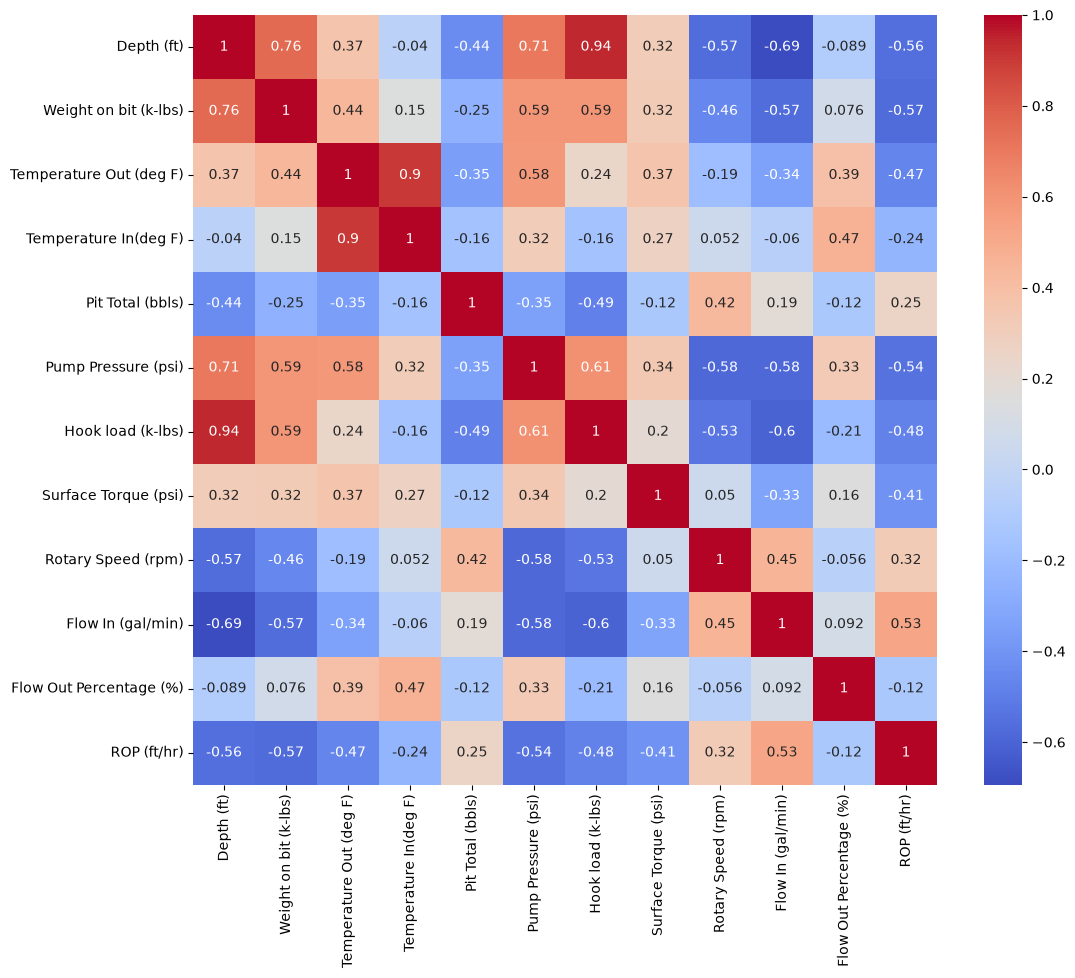

In [11]:
# Heat map - Shows the correlation between the features and the target variable 
import matplotlib.pyplot as plt
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

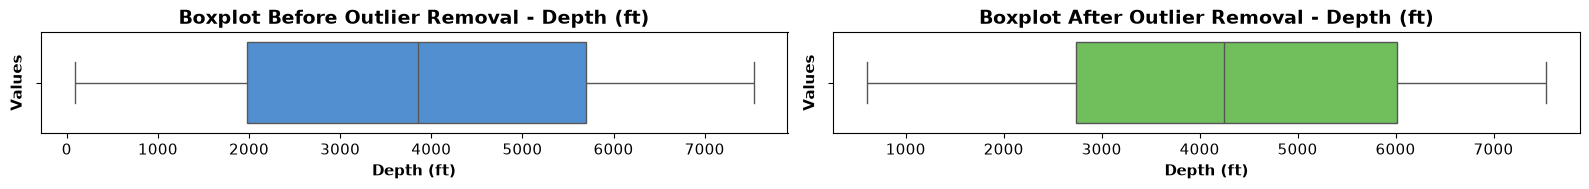

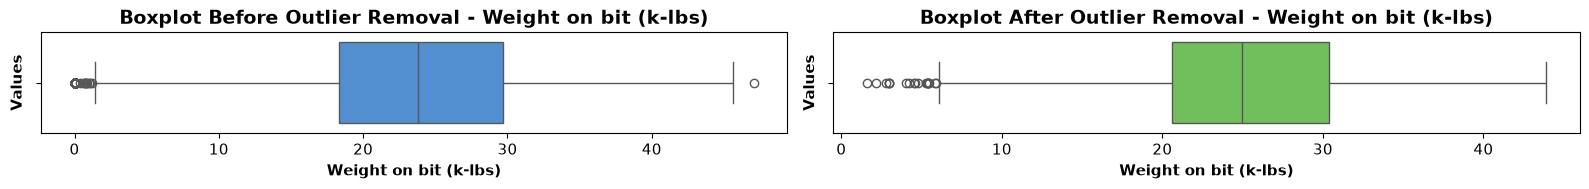

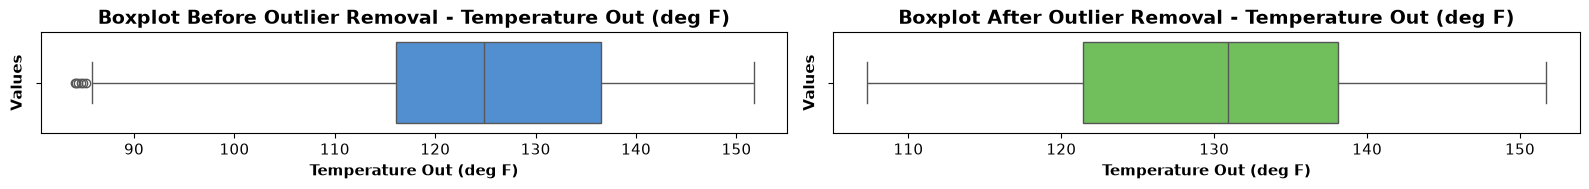

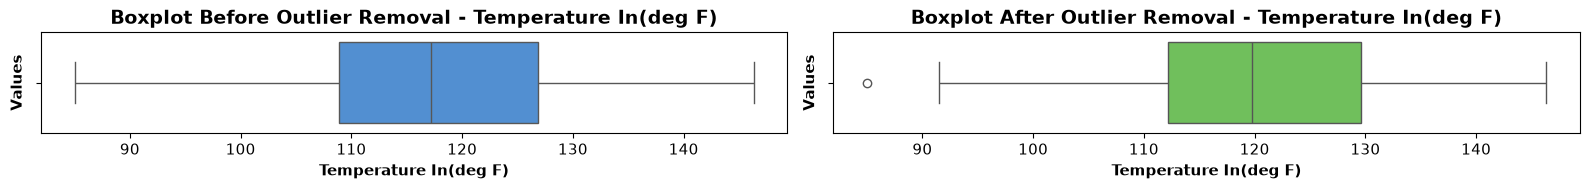

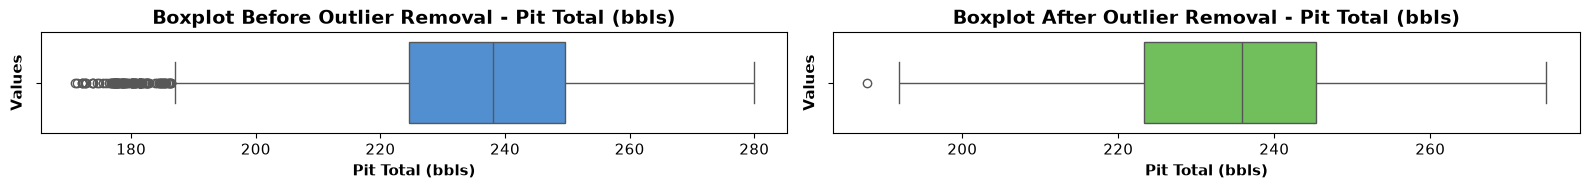

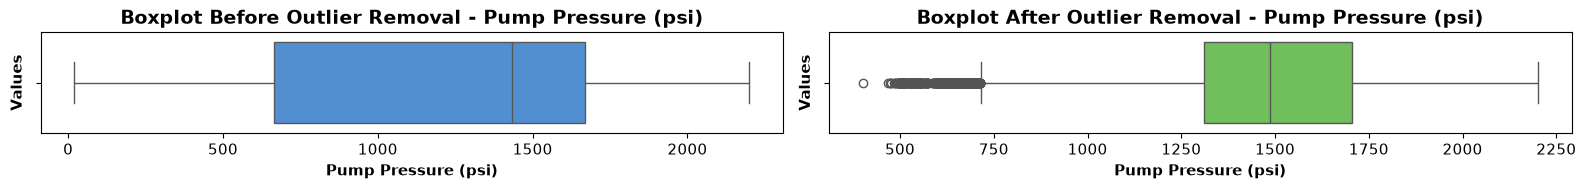

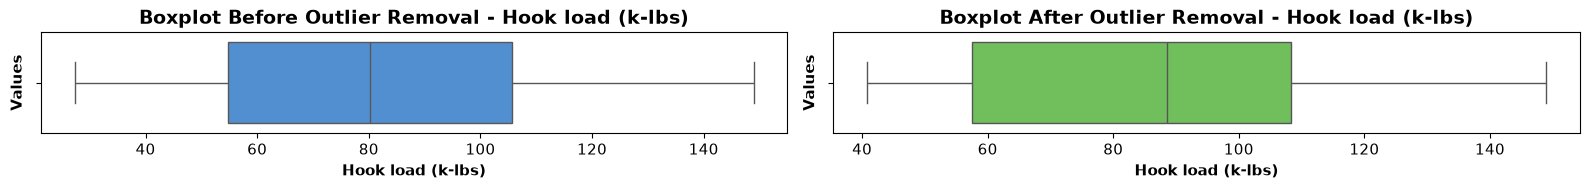

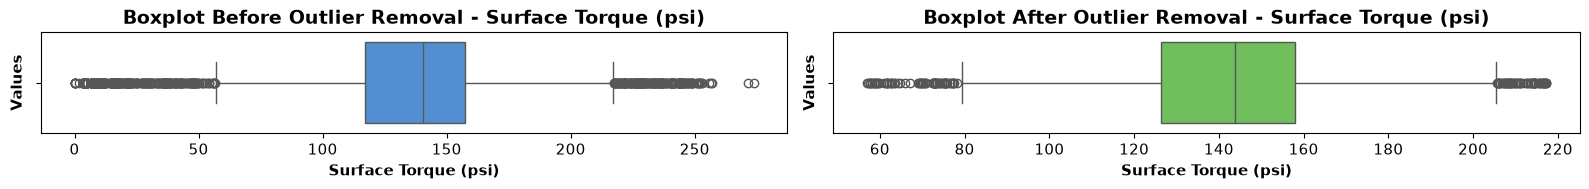

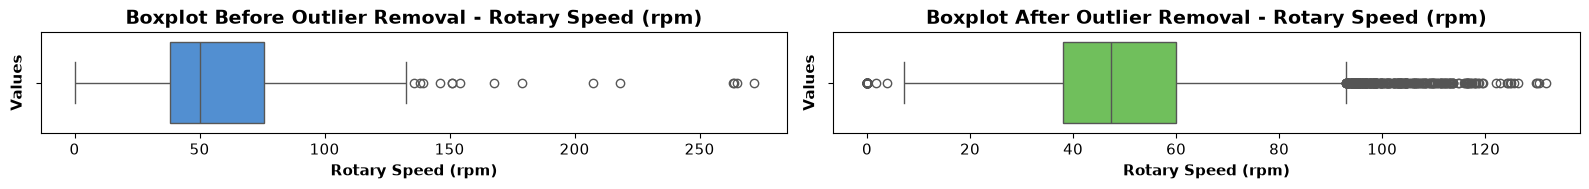

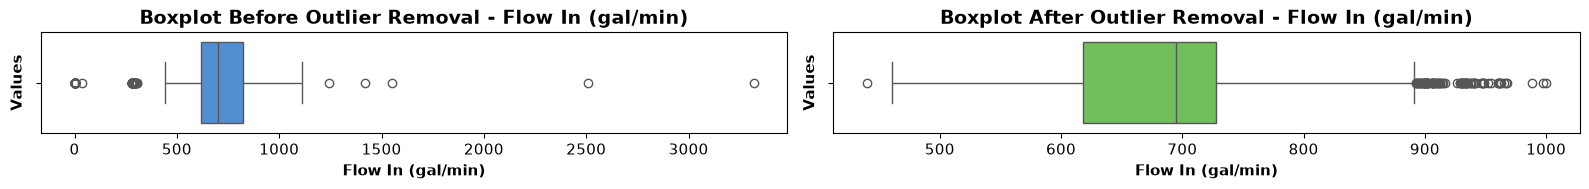

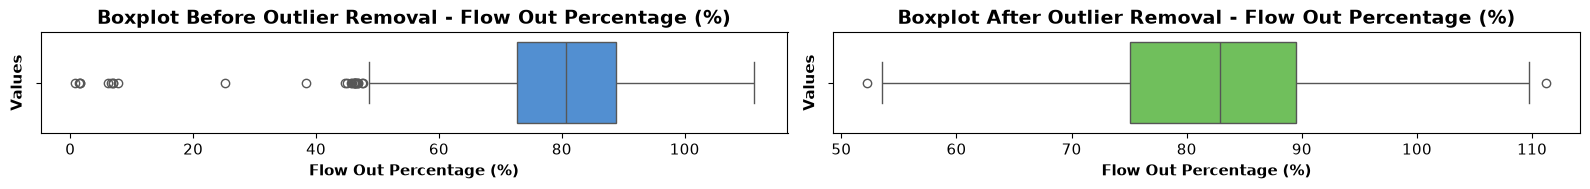

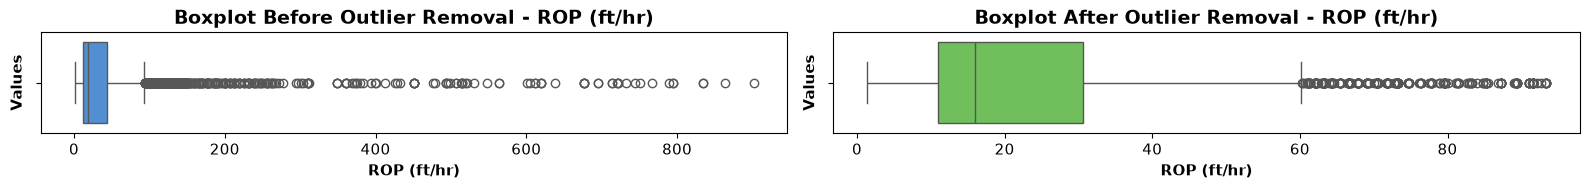

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Features and also for target variable
features = df.columns

def remove_outliers(df, features):
    # Calculation of the Interquartile Range (IQR) for each feature
    Q1 = df[features].quantile(0.25)
    Q3 = df[features].quantile(0.75)
    IQR = Q3 - Q1
    
    # Calculation of the lower and upper bounds for outlier detection
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Row-wise filtering: Keep rows where ALL features fall within the valid range
    non_outlier_mask = ((df[features] >= lower_bound) & (df[features] <= upper_bound)).all(axis=1)
    
    return df[non_outlier_mask].copy()

# Assign the result of the function to data_no_outliers
data_no_outliers = remove_outliers(df, features)

# Saving the data without outliers to a new CSV file
data_no_outliers.to_csv('data_no_outliers.csv', index=False) 

# Visualize boxplots side-by-side (1 row, 2 columns per feature)
for feature in features:
    # Set a clean canvas size (16 inches wide, 4 inches tall)
    fig, axes = plt.subplots(1, 2, figsize=(16, 2))
    
    # 1. Left Plot: Before Outlier Removal
    sns.boxplot(x=df[feature], ax=axes[0], color="#3d8ee6")
    axes[0].set_title(f'Boxplot Before Outlier Removal - {feature}', fontsize=14, weight='bold')
    axes[0].set_xlabel(feature, fontsize=11, weight='bold')
    axes[0].set_ylabel('Values', fontsize=11, weight='bold')
    axes[0].tick_params(labelsize=11)

    # 2. Right Plot: After Outlier Removal
    sns.boxplot(x=data_no_outliers[feature], ax=axes[1], color="#66cf4c")
    axes[1].set_title(f'Boxplot After Outlier Removal - {feature}', fontsize=14, weight='bold')
    axes[1].set_xlabel(feature, fontsize=11, weight='bold')
    axes[1].set_ylabel('Values', fontsize=11, weight='bold')
    axes[1].tick_params(labelsize=11)

    # Ensures proper layout spacing and displays the paired row
    plt.tight_layout()
    plt.show()

In [13]:
# splitting of data into training and testing data

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [14]:
## Scale Data - Very important for KNN as it is distance based algorithm

scalar =StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

In [15]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
# 1. Define the parameter grid you want to search through
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean']
}

# 2. Initialize the base KNN model
knn_base = KNeighborsRegressor()

# 3. Set up GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(estimator=knn_base, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# 4. Fit the grid search to your scaled training data
grid_search.fit(X_train_scaled, Y_train)

# 5. Extract the best parameters and the best model
best_params = grid_search.best_params_
knn_best = grid_search.best_estimator_

print(f"Best tuned parameters found: {best_params}")

# 6. Make predictions using the best tuned model
y_pred = knn_best.predict(X_test_scaled)

Best tuned parameters found: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'}


In [16]:
print(y_pred)

[ 17.94527924  11.48765665   8.03301732 ... 120.10768285  24.31700484
   7.58425942]


In [17]:
# Model Evaluation 

r2=r2_score(Y_test, y_pred)
rmse=np.sqrt(mean_squared_error(Y_test, y_pred))
mae=mean_absolute_error(Y_test, y_pred)
mape_test = np.mean(np.abs((Y_test - y_pred) / Y_test)) * 100





In [18]:
print('R2 =', r2)
print('RMSE =', rmse)
print('MAE =', mae)
print('MAPE =', mape_test)

R2 = 0.8407973792222343
RMSE = 29.548377409888797
MAE = 9.099919824253323
MAPE = 19.777388334394875


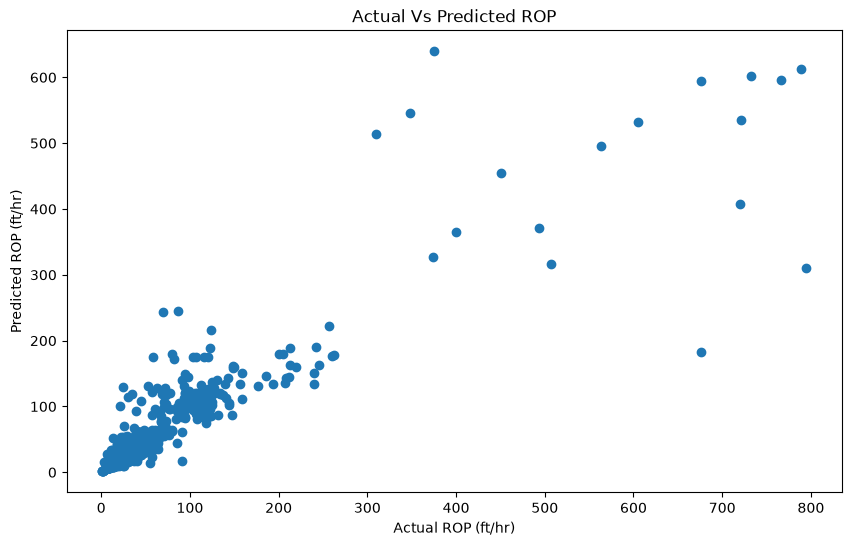

In [19]:
# Actual Vs Predicted Plot 
plt.figure(figsize=(10,6))
plt.scatter(Y_test, y_pred)
plt.xlabel('Actual ROP (ft/hr)')
plt.ylabel('Predicted ROP (ft/hr)')
plt.title('Actual Vs Predicted ROP')
plt.show()

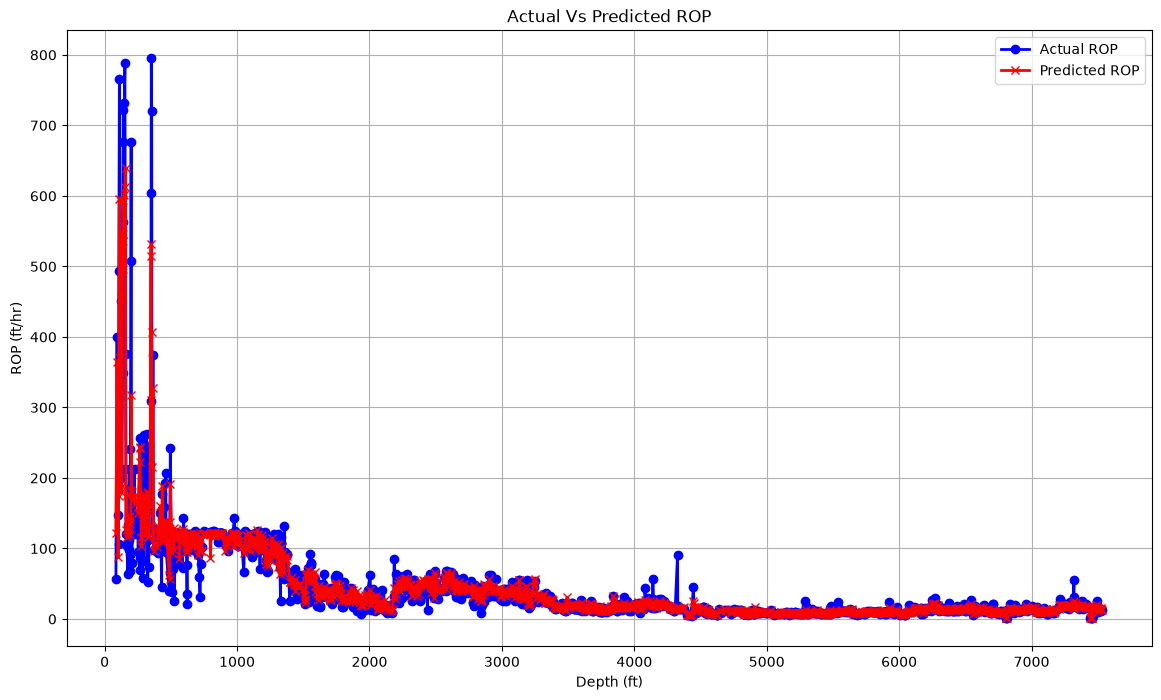

In [20]:
# Creating a results dataframe to compare actual and predicted values
results = X_test.copy()
results['Actual_ROP'] = Y_test
results['Predicted_ROP'] = y_pred

# Sort by depth to see how the model performs at different depths
results = results.sort_values('Depth (ft)')

plt.figure(figsize=(14, 8))

plt.plot(results['Depth (ft)'], results['Actual_ROP'], label='Actual ROP', color='blue', marker='o', linewidth=2)
plt.plot(results['Depth (ft)'], results['Predicted_ROP'], label='Predicted ROP', color='red', marker='x', linewidth=2)
plt.xlabel('Depth (ft)')
plt.ylabel('ROP (ft/hr)')
plt.title('Actual Vs Predicted ROP')
plt.legend()
plt.grid(True)
plt.show()

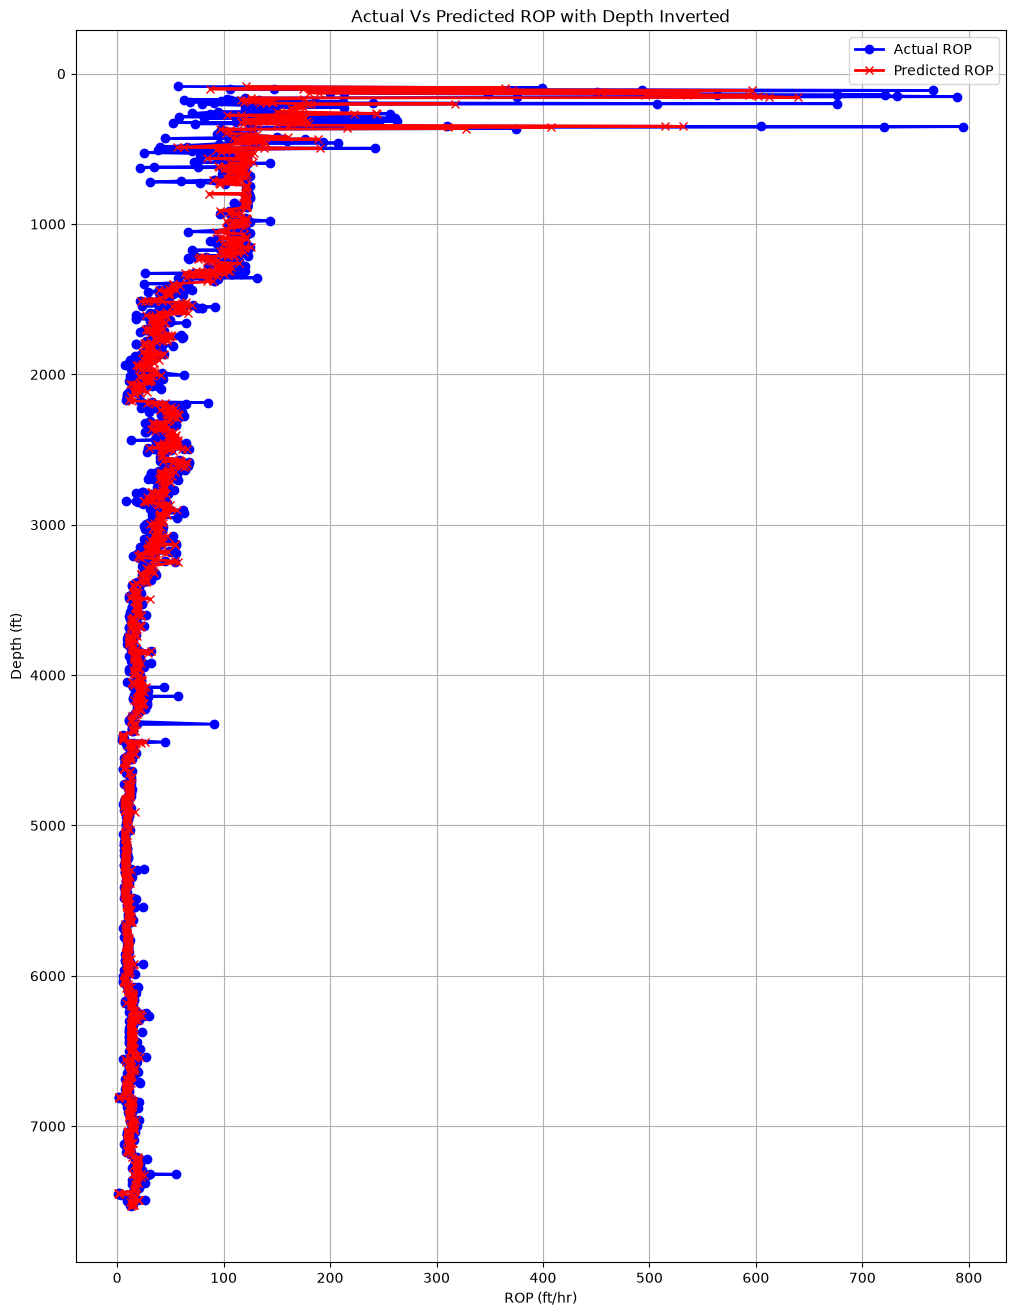

In [21]:
plt.figure(figsize=(12,16)) 
plt.plot(results['Actual_ROP'],results['Depth (ft)'], label='Actual ROP', color='blue', marker='o', linewidth=2)
plt.plot(results['Predicted_ROP'],results['Depth (ft)'], label='Predicted ROP', color='red', marker='x', linewidth=2)
plt.gca().invert_yaxis()  # Invert y-axis to have depth increasing downwards
plt.ylabel("Depth (ft)")
plt.xlabel('ROP (ft/hr)')
plt.title('Actual Vs Predicted ROP with Depth Inverted')
plt.legend()
plt.grid(True)

plt.show()

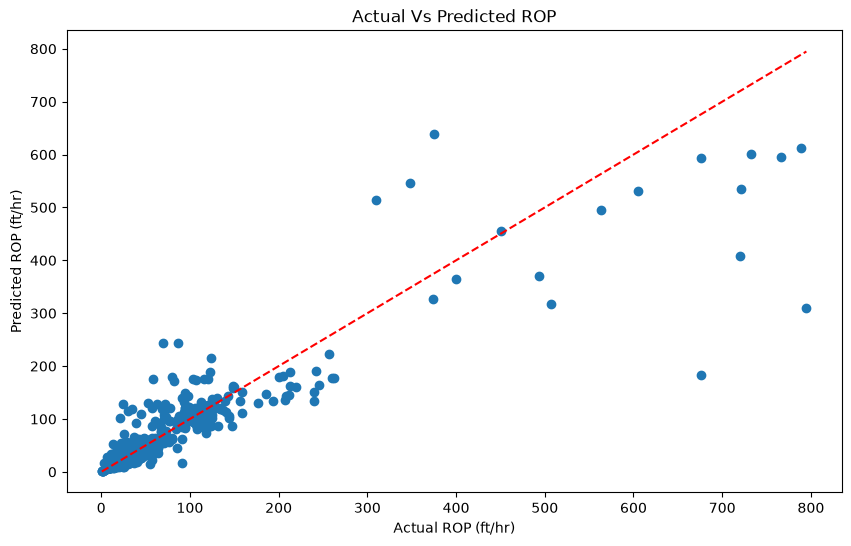

In [22]:
plt.figure(figsize=(10,6))
plt.scatter(Y_test, y_pred)
plt.xlabel('Actual ROP (ft/hr)')
plt.ylabel('Predicted ROP (ft/hr)')
plt.title('Actual Vs Predicted ROP')

min_val = min(min(Y_test), min(y_pred))
max_val = max(max(Y_test), max(y_pred))

plt.plot([min_val, max_val], [min_val, max_val], 'r--',label ="Actual ROP = Predicted ROP ")  # Diagonal line


NameError: name 'mape' is not defined

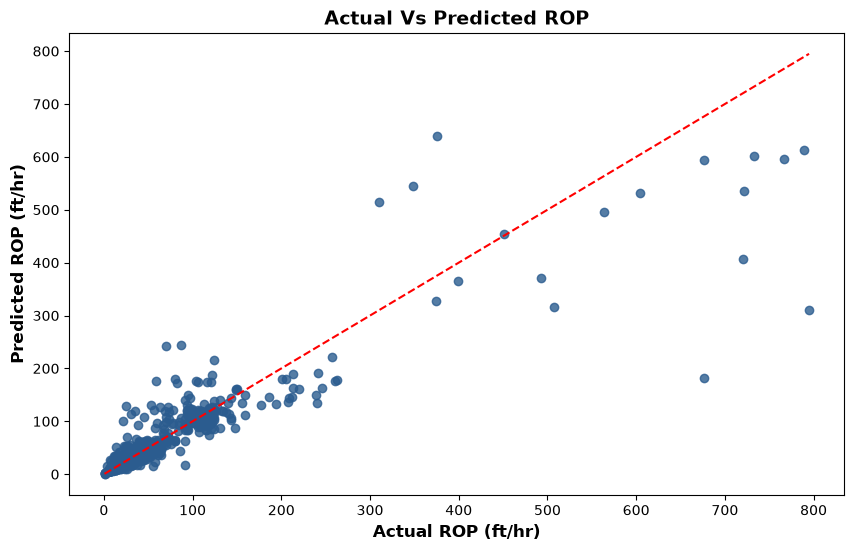

In [23]:

# 2. Plot setup
plt.figure(figsize=(10, 6))

# ADDED LABEL HERE FOR THE BLUE DOTS INDICATOR
plt.scatter(Y_test, y_pred, alpha=0.8, color='#2b5c8f', label="Test Data Points")

plt.xlabel('Actual ROP (ft/hr)', fontsize=12, weight='bold')
plt.ylabel('Predicted ROP (ft/hr)', fontsize=12, weight='bold')
plt.title('Actual Vs Predicted ROP', fontsize=14, weight='bold')

# 3. Diagonal reference line
min_val = min(min(Y_test), min(y_pred))
max_val = max(max(Y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Perfect Prediction Line") 

# 4. Create string text for metrics box
metrics_box = (
    f"R²: {r2:.3f}\n"
    f"MAE: {mae:.2f} ft/hr\n"
    f"MAPE: {mape:.2f}%\n"
    f"RMSE: {rmse:.2f} ft/hr"
)

# Place text box in top-left corner
box_properties = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray')
plt.text(0.05, 0.95, metrics_box, transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top', bbox=box_properties, fontfamily='monospace')

# 5. This will now show indicators for BOTH the dots and the line
plt.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

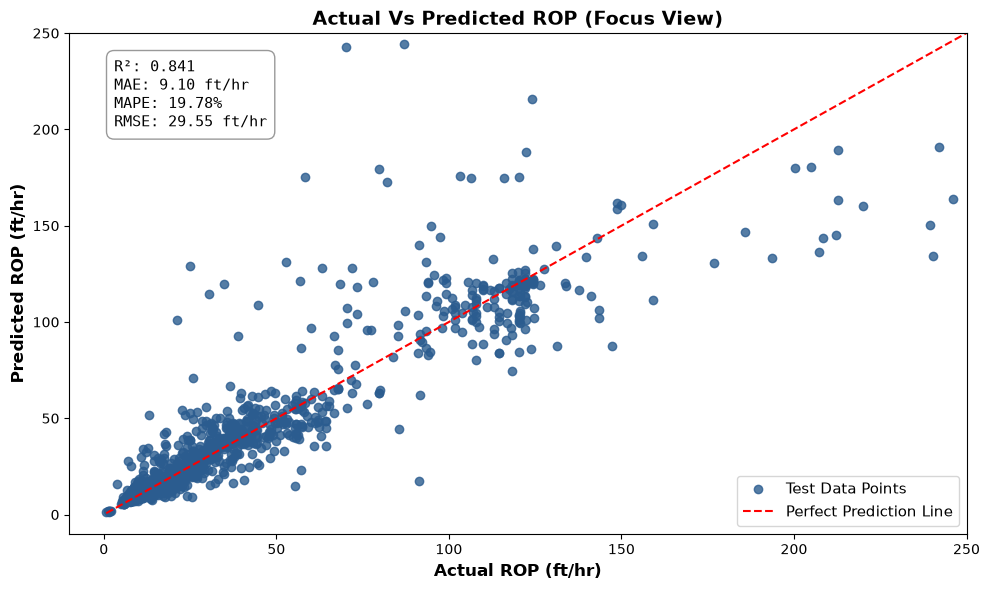

In [ ]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Calculate evaluation metrics
r2 = r2_score(Y_test, y_pred)
mae = mean_absolute_error(Y_test, y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, y_pred))
mape = np.mean(np.abs((Y_test - y_pred) / (Y_test + 1e-10))) * 100

# 2. Plot setup
plt.figure(figsize=(10, 6))
plt.scatter(Y_test, y_pred, alpha=0.8, color='#2b5c8f', label="Test Data Points")

plt.xlabel('Actual ROP (ft/hr)', fontsize=12, weight='bold')
plt.ylabel('Predicted ROP (ft/hr)', fontsize=12, weight='bold')
plt.title('Actual Vs Predicted ROP (Focus View)', fontsize=14, weight='bold')

# 3. Diagonal reference line
min_val = min(min(Y_test), min(y_pred))
max_val = max(max(Y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Perfect Prediction Line") 

# ==========================================
# ADDED FOCUS AREA LIMITS (Zooming into 0-250)
# ==========================================
plt.xlim(-10, 250)
plt.ylim(-10, 250)

# 4. Create string text for metrics box (Moved down slightly to clear the focused line)
metrics_box = (
    f"R²: {r2:.3f}\n"
    f"MAE: {mae:.2f} ft/hr\n"
    f"MAPE: {mape:.2f}%\n"
    f"RMSE: {rmse:.2f} ft/hr"
)

box_properties = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray')
plt.text(0.05, 0.95, metrics_box, transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top', bbox=box_properties, fontfamily='monospace')

# 5. Display indicators
plt.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

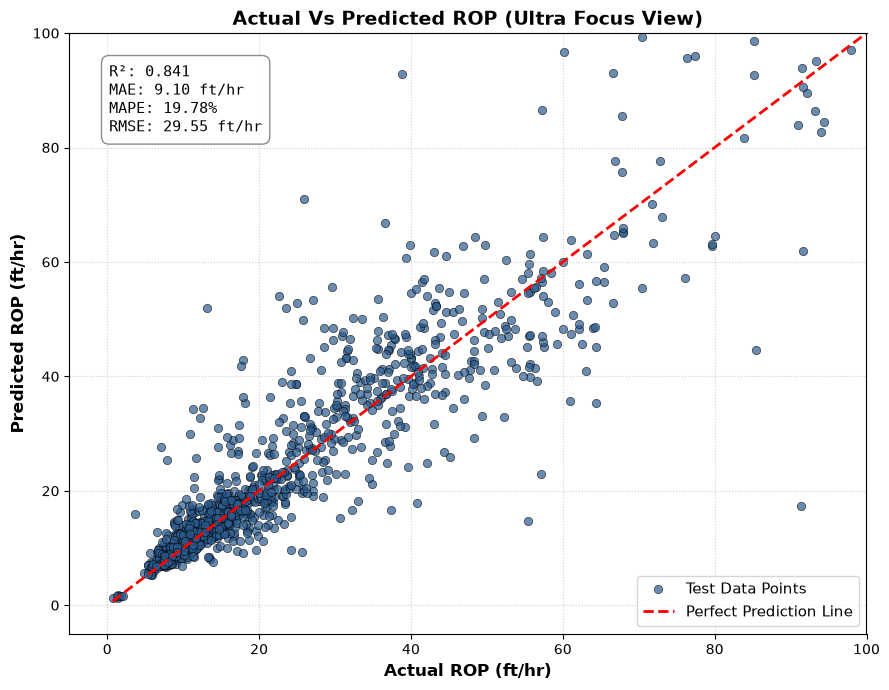

In [ ]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Calculate evaluation metrics
r2 = r2_score(Y_test, y_pred)
mae = mean_absolute_error(Y_test, y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, y_pred))
mape = np.mean(np.abs((Y_test - y_pred) / (Y_test + 1e-10))) * 100

# 2. Plot setup
plt.figure(figsize=(9, 7))  # Made slightly more square for a balanced zoom view
plt.scatter(Y_test, y_pred, alpha=0.7, color='#2b5c8f', edgecolors='k', linewidth=0.5, label="Test Data Points")

plt.xlabel('Actual ROP (ft/hr)', fontsize=12, weight='bold')
plt.ylabel('Predicted ROP (ft/hr)', fontsize=12, weight='bold')
plt.title('Actual Vs Predicted ROP (Ultra Focus View)', fontsize=14, weight='bold')

# 3. Diagonal reference line
min_val = min(min(Y_test), min(y_pred))
max_val = max(max(Y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label="Perfect Prediction Line") 

# ==========================================
# ULTRA FOCUS AREA LIMITS (Zoomed into 0-150)
# ==========================================
plt.xlim(-5, 100)
plt.ylim(-5, 100)

# Add grid lines to make tracking individual points easier in tight space
plt.grid(True, linestyle=':', alpha=0.6)

# 4. Create string text for metrics box
metrics_box = (
    f"R²: {r2:.3f}\n"
    f"MAE: {mae:.2f} ft/hr\n"
    f"MAPE: {mape:.2f}%\n"
    f"RMSE: {rmse:.2f} ft/hr"
)

# Position changed to 'upper left' but adjusted nicely for the tight window
box_properties = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray')
plt.text(0.05, 0.95, metrics_box, transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top', bbox=box_properties, fontfamily='monospace')

# 5. Display indicators
plt.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()